# FEE3411 Control Systems A — MATLAB to Python reference

**A companion to Khalil Appendix D and Nise Appendix B.**

Every computational example in the two set texts is written in MATLAB. This notebook gives the
`python-control` equivalent of each command those appendices use, so that a student without a MATLAB
licence can follow the same worked examples on a free toolchain.

### What this notebook is for

The software in FEE3411 is a **checking tool, not the primary instrument**. In Weeks 8, 10 and 11 you
sketch root loci, Bode plots and Nyquist diagrams *by hand* — that is the skill being examined. The
computer's job is to tell you whether your sketch was right. Because of that, which tool you use
matters much less than whether you drew the thing first.

So: use MATLAB if you have it. Use this if you don't. Either is acceptable for the analysis work in
this unit.

### The one exception

**Week 9 and Assignment 4 use Simulink, and there is no Python substitute.** See the final section.

---

### Installation

Everything here needs three packages:

```
pip install control sympy matplotlib
```

`control` is the Python Control Systems Library. Its API deliberately mirrors the MATLAB Control
System Toolbox, so most commands transfer almost unchanged.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import control as ct
import sympy as sp

print("python-control version:", ct.__version__)
print("sympy version:", sp.__version__)

# A sensible default figure size for this notebook
plt.rcParams["figure.figsize"] = (7, 4.5)
plt.rcParams["axes.grid"] = True

python-control version: 0.10.2
sympy version: 1.14.0


---
## 1. Command reference

Every MATLAB command used in Khalil Appendix D and listed in Nise Appendix B §B.3, restricted to the
FEE3411 syllabus. Commands relating to state space and digital control are omitted — neither is in
this unit's syllabus.

### Building and manipulating transfer functions

| MATLAB | Python (`control` as `ct`) | Note |
|---|---|---|
| `tf(num,den)` | `ct.tf(num, den)` | identical |
| `zpk(z,p,k)` | `ct.zpk(z, p, k)` | use `[]` for no zeros in both |
| `s = tf('s')` | `s = ct.tf('s')` | identical; lets you write `G = 1/(s+1)` |
| `pole(G)` | `ct.poles(G)` | **plural** in Python |
| `zero(G)` | `ct.zeros(G)` | **plural** in Python |
| `dcgain(G)` | `ct.dcgain(G)` | identical |
| `roots(P)` | `np.roots(P)` | numpy, not control |
| `poly([-a -b])` | `np.poly([-a, -b])` | numpy |
| `conv(a,b)` | `np.convolve(a, b)` | numpy |
| `polyval(P,a)` | `np.polyval(P, a)` | numpy |
| `minreal(G)` | `ct.minreal(G)` | identical |
| `tfdata(G,'v')` | `ct.tfdata(G)` | returns nested arrays |
| `tf2zp` / `zp2tf` | `ct.zeros` / `ct.poles`, or `ct.zpk` | no direct one-liner |
| `residue(num,den)` | `sp.apart(...)` | symbolic; see §5 |
| `pade(T,n)` | `ct.pade(T, n)` | identical |

### Interconnecting systems

| MATLAB | Python | Note |
|---|---|---|
| `G1*G2` or `series(G1,G2)` | `G1*G2` or `ct.series(G1,G2)` | identical |
| `G1+G2` or `parallel(G1,G2)` | `G1+G2` or `ct.parallel(G1,G2)` | identical |
| `feedback(G,H)` | `ct.feedback(G, H)` | identical; `sign=+1` for positive feedback in both |

### Time response

| MATLAB | Python | Note |
|---|---|---|
| `step(G)` | `ct.step_response(G)` then plot, or `ct.step_response(G).plot()` | Python returns data by default |
| `stepinfo(G)` | `ct.step_info(G)` | returns a `dict`, not a struct |
| `impulse(G)` | `ct.impulse_response(G)` | as above |
| `lsim(G,u,t)` | `ct.forced_response(G, T=t, U=u)` | argument names differ |
| `damp(G)` | `ct.damp(G)` | returns `(wn, zeta, poles)` |
| `ord2(wn,z)` | write it out: `ct.tf([wn**2],[1,2*z*wn,wn**2])` | no equivalent |

### Root locus

| MATLAB | Python | Note |
|---|---|---|
| `rlocus(G)` | `ct.root_locus_plot(G)` | identical behaviour |
| `sgrid` | `ct.root_locus_plot(G, grid=True)` | built into the plot call |
| `rlocfind(G)` | *no direct equivalent* | see §8 for the workaround |

### Frequency response

| MATLAB | Python | Note |
|---|---|---|
| `bode(G)` | `ct.bode_plot(G, dB=True)` | **Python defaults to magnitude ratio, not dB** |
| `[M,P,w]=bode(G)` | `ct.frequency_response(G, omega)` | returns magnitude (ratio), phase (rad), omega |
| `nyquist(G)` | `ct.nyquist_plot(G)` | identical |
| `nichols(G)` | `ct.nichols_plot(G)` | identical |
| `ngrid` | `ct.nichols_grid()` | identical |
| `margin(G)` | `ct.margin(G)` | **returns gain margin as a ratio, not dB** |
| `allmargin(G)` | `ct.stability_margins(G)` | |
| `bandwidth(T)` | `ct.bandwidth(T)` | identical |

### Two differences that catch people out

1. **`ct.margin` returns the gain margin as a plain ratio.** MATLAB's `margin` plot labels it in dB.
   Convert with `20*np.log10(gm)`.
2. **`ct.bode_plot` defaults to a magnitude *ratio* on a log axis, not dB.** Pass `dB=True` to match
   the textbooks. Phase is in degrees by default in both, which is what you want.

Get these two wrong and your numbers will disagree with Khalil and Nise while your code is
technically correct.


---
## 2. Week 3 — Transfer functions and the s-plane

Khalil §D-1. Two ways to define the same transfer function:

$$G(s)=\frac{4(s+2)}{(s+1)(s+3)(s+5)}=\frac{4s+8}{s^{3}+9s^{2}+23s+15}$$


In [2]:
# Polynomial form  -- MATLAB: G = tf([4 8],[1 9 23 15])
G = ct.tf([4, 8], [1, 9, 23, 15])

# Factored form    -- MATLAB: H = zpk(-2,[-1 -3 -5],4)
H = ct.zpk([-2], [-1, -3, -5], 4)

print(G)

<TransferFunction>: sys[0]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

          4 s + 8
  -----------------------
  s^3 + 9 s^2 + 23 s + 15


In [3]:
# MATLAB: pole(G), zero(G), dcgain(G)   -- note the plurals in Python
print("poles  :", ct.poles(G))
print("zeros  :", ct.zeros(G))
print("DC gain:", ct.dcgain(G))

# MATLAB: roots([1 9 23 15])
print("roots  :", np.roots([1, 9, 23, 15]))

poles  : [-5.+0.j -3.+0.j -1.+0.j]
zeros  : [-2.+0.j]
DC gain: 0.5333333333333333
roots  : [-5. -3. -1.]


The `s = tf('s')` idiom is often the most readable way to enter a transfer function, and it works
identically in both languages.

In [4]:
s = ct.tf('s')
G_alt = 4 * (s + 2) / ((s + 1) * (s + 3) * (s + 5))
print(G_alt)

<TransferFunction>: sys[14]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

          4 s + 8
  -----------------------
  s^3 + 9 s^2 + 23 s + 15


### The pole-zero map

MATLAB has `pzmap`. In Python, plot `ct.poles` and `ct.zeros` yourself — three lines, and it makes the
convention explicit: poles are crosses, zeros are circles.

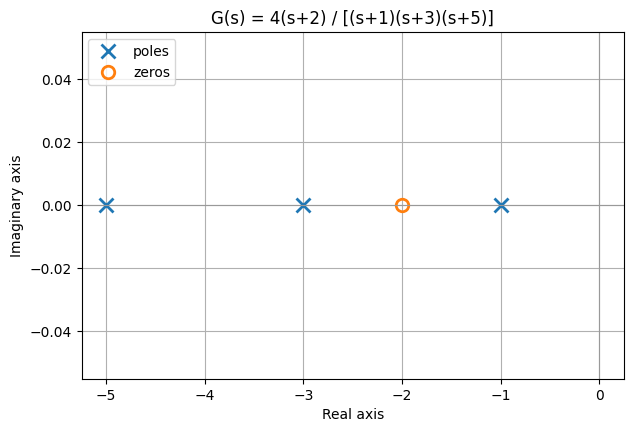

In [5]:
def pzmap(sys, title="Pole-zero map"):
    p, z = ct.poles(sys), ct.zeros(sys)
    fig, ax = plt.subplots()
    ax.plot(p.real, p.imag, 'x', markersize=10, markeredgewidth=2, label='poles')
    if len(z):
        ax.plot(z.real, z.imag, 'o', markersize=9, fillstyle='none',
                markeredgewidth=2, label='zeros')
    ax.axhline(0, color='0.6', lw=0.8)
    ax.axvline(0, color='0.6', lw=0.8)
    ax.set_xlabel('Real axis'); ax.set_ylabel('Imaginary axis')
    ax.set_title(title); ax.legend()
    return ax

pzmap(G, "G(s) = 4(s+2) / [(s+1)(s+3)(s+5)]")
plt.show()

---
## 3. Week 4 — Block diagrams and interconnection

Khalil §D-1. These map one-to-one. The operator forms (`*`, `+`) are usually clearer than the
function forms in both languages.

In [6]:
H1 = ct.tf(1, [1, 1])
H2 = ct.tf(4, [1, 2])

Hs = H1 * H2                 # series      -- MATLAB: H1*H2
Hp = H1 + H2                 # parallel    -- MATLAB: H1+H2
Hf = ct.feedback(H1, H2)     # feedback    -- MATLAB: feedback(H1,H2)

print("Series:\n",   Hs)
print("Parallel:\n", Hp)
print("Feedback:\n", Hf)

Series:
 <TransferFunction>: sys[17]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

        4
  -------------
  s^2 + 3 s + 2
Parallel:
 <TransferFunction>: sys[18]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

     5 s + 6
  -------------
  s^2 + 3 s + 2
Feedback:
 <TransferFunction>: sys[19]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

      s + 2
  -------------
  s^2 + 3 s + 6


**Signal flow graphs and Mason's rule have no software equivalent in either language.** Mason's
formula is a hand method — that is the point of it. Use `ct.feedback` and `*` to *check* the closed-loop
transfer function you derived by hand.

---
## 4. Week 5 — Transient response

Khalil §D-1. A standard second-order system with $\omega_n = 5$, $\zeta = 0.5$:

$$G(s)=\frac{\omega_n^{2}}{s^{2}+2\zeta\omega_n s+\omega_n^{2}}$$


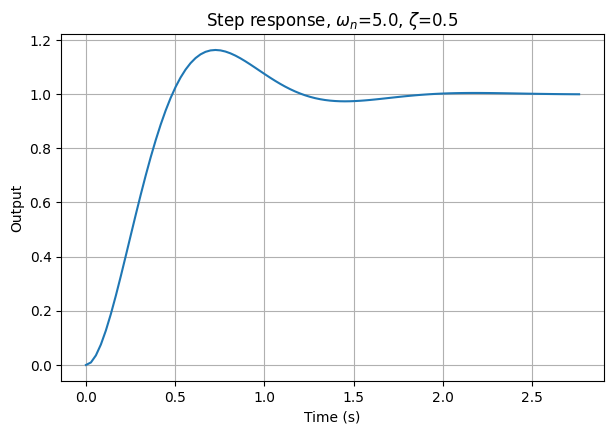

In [7]:
wn, zeta = 5.0, 0.5
G2 = ct.tf([wn**2], [1, 2*zeta*wn, wn**2])

# MATLAB: step(G)
t, y = ct.step_response(G2)
plt.plot(t, y)
plt.xlabel('Time (s)'); plt.ylabel('Output')
plt.title(f'Step response, $\\omega_n$={wn}, $\\zeta$={zeta}')
plt.show()

In [8]:
# MATLAB: stepinfo(G) -- Python returns a dict rather than a struct
info = ct.step_info(G2)
for k, v in info.items():
    print(f"{k:20s} {v:.4f}")

# Check against the closed-form overshoot for a second-order system with no zero
theory = 100 * np.exp(-zeta * np.pi / np.sqrt(1 - zeta**2))
print(f"\nTheoretical overshoot: {theory:.2f} %")

RiseTime             0.3349
SettlingTime         1.6188
SettlingMin          0.9395
SettlingMax          1.1630
Overshoot            16.3033
Undershoot           0.0000
Peak                 1.1630
PeakTime             0.7257
SteadyStateValue     1.0000

Theoretical overshoot: 16.30 %


### Response to an arbitrary input

Khalil §D-1 uses a ramp $u = 2t$. MATLAB's `lsim` becomes `ct.forced_response`.

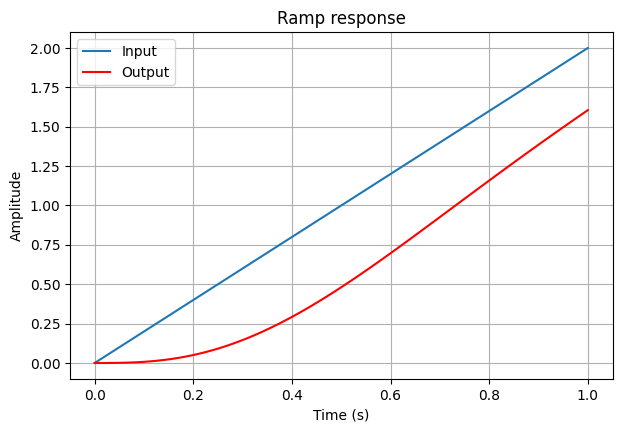

In [9]:
t = np.arange(0, 1.001, 0.01)
u = 2 * t

# MATLAB: y = lsim(G,u,t)
resp = ct.forced_response(G2, T=t, U=u)

plt.plot(t, u, label='Input')
plt.plot(resp.time, resp.outputs, 'r', label='Output')
plt.xlabel('Time (s)'); plt.ylabel('Amplitude'); plt.legend()
plt.title('Ramp response')
plt.show()

### Time delay

MATLAB writes `tf(1,1,'InputDelay',T)`. `python-control` transfer functions do not carry a delay
attribute, so use a Padé approximation — which is what you would do for Bode and Nyquist work anyway
(Nise §10.12, Sundararajan §9.2.4).

In [10]:
T_delay = 0.5
num, den = ct.pade(T_delay, 3)      # MATLAB: pade(T,n)
delay_approx = ct.tf(num, den)
print(f"3rd-order Pade approximation of exp(-{T_delay}s):\n", delay_approx)

3rd-order Pade approximation of exp(-0.5s):
 <TransferFunction>: sys[26]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

  -s^3 + 24 s^2 - 240 s + 960
  ---------------------------
  s^3 + 24 s^2 + 240 s + 960


---
## 5. Week 6 — Steady-state errors and error constants

Khalil §D-3. The technique is the same in both languages: multiply by $s$ (or $s^2$), cancel the pole
at the origin with `minreal`, then take the DC gain.

In [11]:
s = ct.tf('s')

# Kp for a type 0 system  -- MATLAB: G0 = tf(12,[1 6 11 6]); Kp = dcgain(G0)
G0 = ct.tf(12, [1, 6, 11, 6])
Kp = ct.dcgain(G0)

# Kv for a type 1 system  -- multiply by s, cancel, take DC gain
G1 = ct.zpk([], [0, -1, -2], 10)
Kv = ct.dcgain(ct.minreal(s * G1, verbose=False))

# Ka for a type 2 system  -- multiply by s^2
G2t = ct.zpk([], [0, 0, -2], 6)
Ka = ct.dcgain(ct.minreal(s**2 * G2t, verbose=False))

print(f"Kp = {Kp}   ->  e_ss (step)     = {1/(1+Kp):.4f}")
print(f"Kv = {Kv}   ->  e_ss (ramp)     = {1/Kv:.4f}")
print(f"Ka = {Ka}   ->  e_ss (parabola) = {1/Ka:.4f}")

Kp = 2.0   ->  e_ss (step)     = 0.3333
Kv = 5.0   ->  e_ss (ramp)     = 0.2000
Ka = 3.0   ->  e_ss (parabola) = 0.3333


### Partial fractions

MATLAB uses `residue`. Python's equivalent is symbolic, via sympy — and arguably better, because it
gives you the inverse Laplace transform directly rather than a table of residues you then have to
assemble by hand.

In [12]:
sy, ty = sp.symbols('s t', positive=True)
F = (4*sy + 8) / (sy**3 + 9*sy**2 + 23*sy + 15)

print("Partial fractions:")
sp.pprint(sp.apart(F, sy))

print("\nInverse Laplace transform:")
sp.pprint(sp.inverse_laplace_transform(F, sy, ty))

Partial fractions:


      3         1         1    
- ───────── + ───── + ─────────
  2⋅(s + 5)   s + 3   2⋅(s + 1)

Inverse Laplace transform:
 -t              -5⋅t
ℯ      -3⋅t   3⋅ℯ    
─── + ℯ     - ───────
 2               2   


---
## 6. Week 7 — Stability and the Routh-Hurwitz criterion

**Neither MATLAB nor `python-control` has a Routh array command.** For numeric coefficients you can
just check the poles. But the exam questions that matter ask for a *range of gain*, and for those
sympy does something MATLAB cannot do without the Symbolic Toolbox: build the array symbolically and
solve the inequalities.

The helper below is the one piece of this notebook worth keeping to hand.

In [13]:
def routh_array(polynomial, var):
    '''Symbolic Routh array. Returns a sympy Matrix; row i corresponds to s^(n-i).'''
    coeffs = sp.Poly(polynomial, var).all_coeffs()
    n = len(coeffs)
    width = (n + 1) // 2
    M = sp.zeros(n, width)
    first = coeffs[0::2]
    second = coeffs[1::2]
    M[0, :len(first)] = sp.Matrix([first])
    M[1, :len(second)] = sp.Matrix([second])
    for i in range(2, n):
        for j in range(width - 1):
            a, b = M[i-2, 0], M[i-1, 0]
            if b == 0:
                b = sp.Symbol('epsilon')     # special case: zero in the first column
            M[i, j] = sp.simplify((b*M[i-2, j+1] - a*M[i-1, j+1]) / b)
    return M

In [14]:
# Characteristic equation of a unity-feedback system with loop gain K/[s(s+1)(s+2)]:
#   s^3 + 3s^2 + 2s + K = 0
sy = sp.Symbol('s')
K = sp.Symbol('K', real=True)

char_eq = sy**3 + 3*sy**2 + 2*sy + K
R = routh_array(char_eq, sy)

print("Routh array:")
sp.pprint(R)

first_column = [sp.simplify(R[i, 0]) for i in range(R.rows)]
print("\nFirst column:", first_column)

conditions = [sp.simplify(c) > 0 for c in first_column if c.free_symbols]
print("\nStable range of K:", sp.solve(conditions, K))

Routh array:
⎡  1    2⎤
⎢        ⎥
⎢  3    K⎥
⎢        ⎥
⎢    K   ⎥
⎢2 - ─  0⎥
⎢    3   ⎥
⎢        ⎥
⎣  K    0⎦

First column: [1, 3, 2 - K/3, K]

Stable range of K: (0 < K) & (K < 6)


In [15]:
# Verify numerically: the system should be stable just below K = 6 and unstable just above
for K_val in (5.9, 6.0, 6.1):
    poles = np.roots([1, 3, 2, K_val])
    stable = np.all(poles.real < 0)
    print(f"K = {K_val:4.1f}   max Re(pole) = {poles.real.max():+.4f}   stable: {stable}")

K =  5.9   max Re(pole) = -0.0046   stable: True
K =  6.0   max Re(pole) = +0.0000   stable: False
K =  6.1   max Re(pole) = +0.0045   stable: False


---
## 7. Week 8 — Root locus

Khalil §D-2. `ct.root_locus_plot` behaves like MATLAB's `rlocus`, and `grid=True` gives you the
constant-$\zeta$ and constant-$\omega_n$ curves that MATLAB's `sgrid` overlays.

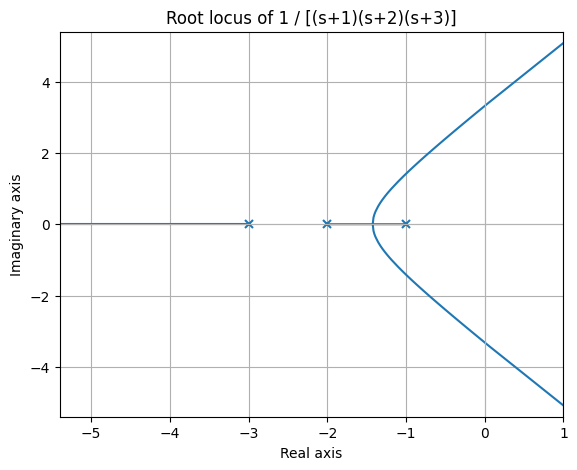

In [16]:
# MATLAB: G = zpk([],[-1 -2 -3],1); rlocus(G)
G_rl = ct.zpk([], [-1, -2, -3], 1)

fig, ax = plt.subplots(figsize=(6.5, 5))
ct.root_locus_plot(G_rl, ax=ax, title='')
ax.set_title('Root locus of 1 / [(s+1)(s+2)(s+3)]')
ax.set_xlabel('Real axis'); ax.set_ylabel('Imaginary axis')
ax.axhline(0, color='0.7', lw=0.8); ax.axvline(0, color='0.7', lw=0.8)
plt.show()

Check this against what you sketched by hand: three branches starting at $-1$, $-2$, $-3$;
real-axis segments between $-1$ and $-2$ and to the left of $-3$; asymptote centroid at
$(-1-2-3)/3 = -2$ with asymptote angles $\pm 60^{\circ}$ and $180^{\circ}$; a breakaway point
near $-1.42$; and a $j\omega$-axis crossing at the gain where the system goes unstable.

### The `sgrid` equivalent

Passing `grid=True` overlays constant-$\zeta$ rays and constant-$\omega_n$ arcs, the equivalent of
MATLAB's `sgrid`.

> **Quirk worth knowing.** `python-control` draws this grid with a curvilinear axis helper, and the
> tick labels lose their minus signs — the pole at $-3$ is labelled `3.0`. The plot is correct; the
> labels are misleading. Read positions off the grid, not off the tick labels, or use the plain plot
> above when you need to read exact coordinates.

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


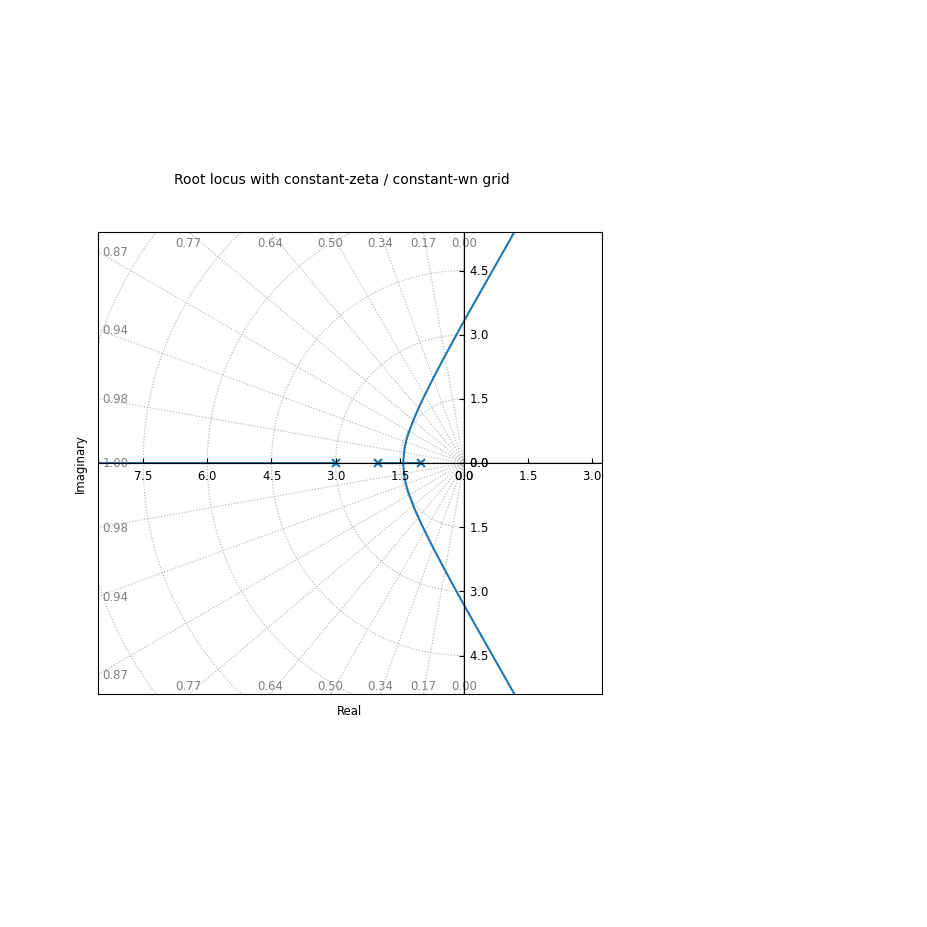

In [17]:
plt.figure(figsize=(6.5, 6))
ct.root_locus_plot(G_rl, grid=True, title='Root locus with constant-zeta / constant-wn grid')
plt.show()

### Replacing `rlocfind`

MATLAB's `rlocfind` lets you click a point on the locus and reports the gain and the closed-loop poles.
There is no click-to-select equivalent, but the underlying calculation is easy to do directly — and
being explicit about it is arguably better practice, since you can see exactly what is being solved.

In [18]:
def locus_at_gain(G, K):
    '''Closed-loop poles, damping and natural frequency at a given loop gain K.'''
    cl = ct.feedback(K * G, 1)
    p = ct.poles(cl)
    wn, zeta, _ = ct.damp(cl, doprint=False)
    return p, wn, zeta

for K_val in (1, 6, 20):
    p, wn, zeta = locus_at_gain(G_rl, K_val)
    print(f"K = {K_val:>3}")
    print(f"   closed-loop poles : {np.round(p, 4)}")
    print(f"   zeta              : {np.round(zeta, 4)}")
    print(f"   wn                : {np.round(wn, 4)}")

K =   1
   closed-loop poles : [-3.3247+0.j     -1.3376+0.5623j -1.3376-0.5623j]
   zeta              : [1.     0.9219 0.9219]
   wn                : [3.3247 1.451  1.451 ]
K =   6
   closed-loop poles : [-4.+0.j     -1.+1.4142j -1.-1.4142j]
   zeta              : [1.     0.5774 0.5774]
   wn                : [4.     1.7321 1.7321]
K =  20
   closed-loop poles : [-4.8371+0.j     -0.5814+2.2443j -0.5814-2.2443j]
   zeta              : [1.     0.2508 0.2508]
   wn                : [4.8371 2.3184 2.3184]


To find the gain that puts the locus on a particular damping ratio — the Week 9 design task — sweep
and pick the crossing.

In [19]:
def gain_for_damping(G, zeta_target, K_max=100, n=20000):
    '''Smallest K whose dominant closed-loop pole pair has damping <= zeta_target.'''
    for K in np.linspace(1e-3, K_max, n):
        _, zeta, poles = ct.damp(ct.feedback(K * G, 1), doprint=False)
        cplx = np.abs(poles.imag) > 1e-9
        if cplx.any() and zeta[cplx].min() <= zeta_target:
            return K, poles
    return None, None

K_found, poles_found = gain_for_damping(G_rl, 0.5)
print(f"K for zeta = 0.5 : {K_found:.3f}")
print(f"closed-loop poles: {np.round(poles_found, 4)}")

K for zeta = 0.5 : 8.006
closed-loop poles: [-4.1668+0.j     -0.9166+1.5878j -0.9166-1.5878j]


---
## 8. Week 9 — Design by gain adjustment, and checking it

The Week 9 lecture asks you to pick a gain from the root locus to meet a transient specification, then
confirm the prediction against the actual response. Here is that loop end to end.

Design gain K = 8.006
  predicted overshoot for zeta=0.5 : 16.30 %
  actual overshoot                 : 14.44 %
  settling time                    : 4.594 s
  steady-state value               : 0.5716


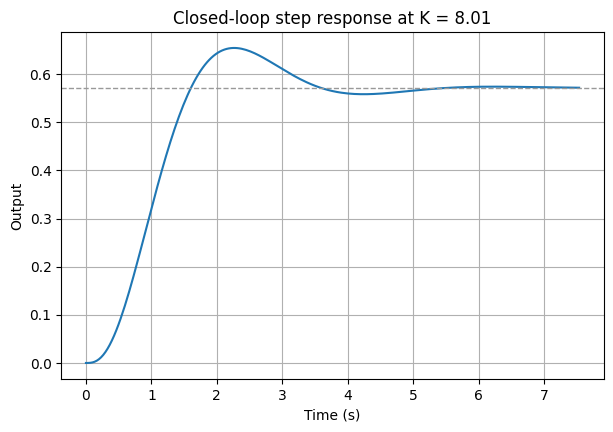

In [20]:
cl = ct.feedback(K_found * G_rl, 1)
info = ct.step_info(cl)

print(f"Design gain K = {K_found:.3f}")
print(f"  predicted overshoot for zeta=0.5 : "
      f"{100*np.exp(-0.5*np.pi/np.sqrt(1-0.5**2)):.2f} %")
print(f"  actual overshoot                 : {info['Overshoot']:.2f} %")
print(f"  settling time                    : {info['SettlingTime']:.3f} s")
print(f"  steady-state value               : {info['SteadyStateValue']:.4f}")

t, y = ct.step_response(cl)
plt.plot(t, y)
plt.axhline(info['SteadyStateValue'], color='0.6', ls='--', lw=1)
plt.xlabel('Time (s)'); plt.ylabel('Output')
plt.title(f'Closed-loop step response at K = {K_found:.2f}')
plt.show()

The gap between the predicted and actual overshoot is the point of the exercise: the
second-order formula assumes a dominant complex pair with no zero, and this plant has a third pole.
Discuss that gap rather than treating it as an error.

---
## 9. Week 10 — Bode plots

Khalil §D-4. **Pass `dB=True`** or your magnitude axis will not match the textbooks.

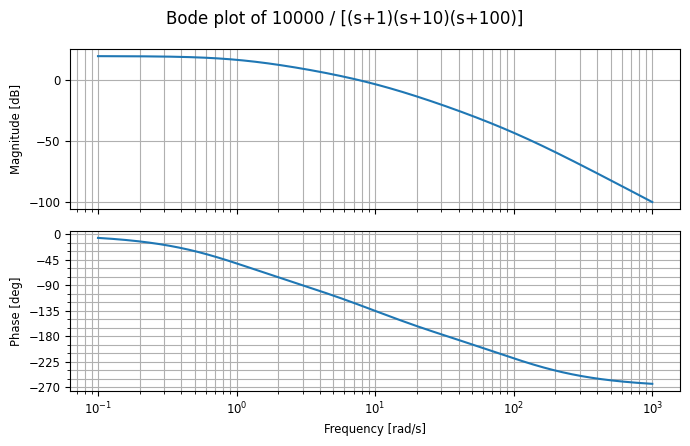

In [21]:
# MATLAB: G = zpk([],[-1 -10 -100],10000); bode(G); grid
G_f = ct.zpk([], [-1, -10, -100], 10000)

ct.bode_plot(G_f, dB=True, deg=True)
plt.suptitle('Bode plot of 10000 / [(s+1)(s+10)(s+100)]')
plt.show()

### Getting the numbers rather than the picture

Khalil §D-4 shows how to extract magnitude and phase and plot them yourself, so that you can overlay
asymptotic sketches on the exact curves. That is exactly the Week 10 tutorial exercise, and it is the
single most useful thing this notebook can do for you: **draw your asymptotes by hand, then overlay the
exact curve and see where you were wrong.**

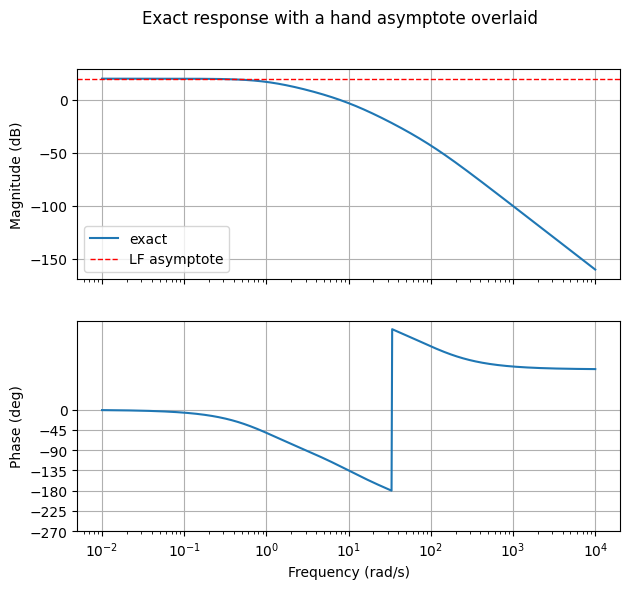

In [22]:
omega = np.logspace(-2, 4, 800)
mag, phase, w = ct.frequency_response(G_f, omega)

mag_dB = 20 * np.log10(mag)          # ct returns a RATIO, not dB
phase_deg = np.degrees(phase)        # ct returns RADIANS

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 6), sharex=True)

ax1.semilogx(w, mag_dB, label='exact')
# Low-frequency asymptote: 20*log10(DC gain), flat
ax1.axhline(20*np.log10(float(ct.dcgain(G_f))), color='r', ls='--', lw=1,
            label='LF asymptote')
ax1.set_ylabel('Magnitude (dB)'); ax1.legend()

ax2.semilogx(w, phase_deg)
ax2.set_ylabel('Phase (deg)'); ax2.set_xlabel('Frequency (rad/s)')
ax2.set_yticks([0, -45, -90, -135, -180, -225, -270])

fig.suptitle('Exact response with a hand asymptote overlaid')
plt.show()

### Stability margins from the Bode plot

Gain margin      : 12.2210 (ratio) = 21.742 dB
Phase margin     : 54.901 deg
at gain crossover: 7.7980 rad/s
at phase crossover: 33.3167 rad/s


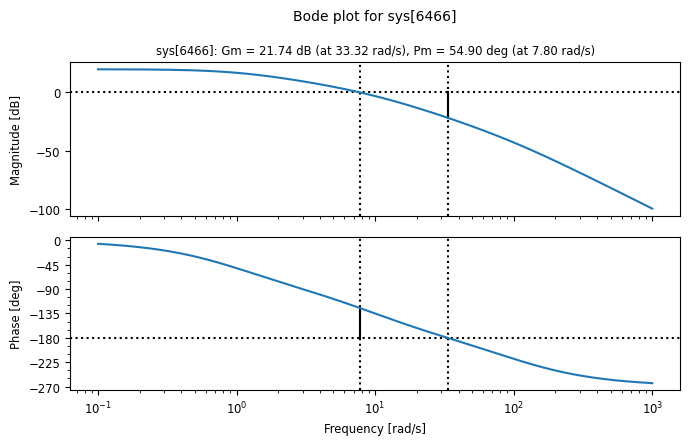

In [23]:
# MATLAB: margin(G)
gm, pm, wcg, wcp = ct.margin(G_f)

print(f"Gain margin      : {gm:.4f} (ratio) = {20*np.log10(gm):.3f} dB")
print(f"Phase margin     : {pm:.3f} deg")
print(f"at gain crossover: {wcp:.4f} rad/s")
print(f"at phase crossover: {wcg:.4f} rad/s")

ct.bode_plot(G_f, dB=True, display_margins=True)
plt.show()

> **The gain margin trap.** `ct.margin` returns the gain margin as a plain ratio; MATLAB's `margin`
> plot annotates it in dB. If your answer is out by a factor that looks like a logarithm, this is why.

---
## 10. Week 11 — Polar plots and the Nyquist diagram

Khalil §D-4. The polar plot and the Nyquist diagram are the same curve; the Nyquist diagram adds the
mirror image for negative frequencies and closes the contour.

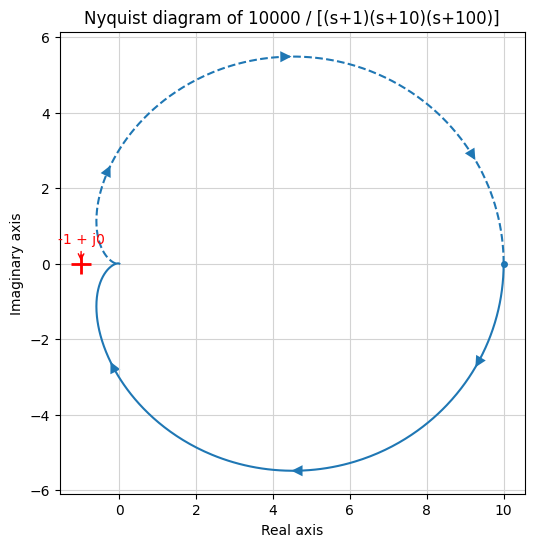

In [24]:
fig, ax = plt.subplots(figsize=(6, 6))
ct.nyquist_plot(G_f, ax=ax)
ax.set_title('Nyquist diagram of 10000 / [(s+1)(s+10)(s+100)]')
ax.plot(-1, 0, 'r+', markersize=14, markeredgewidth=2)
ax.annotate('-1 + j0', xy=(-1, 0), xytext=(-1.6, 0.55),
            arrowprops=dict(arrowstyle='->', color='r'), color='r')
plt.show()

### Just the polar plot

For the Week 11 tutorial you build the plot segment by segment. Plotting the raw frequency response on
the complex plane makes the direction of travel visible, which the packaged `nyquist_plot` hides.

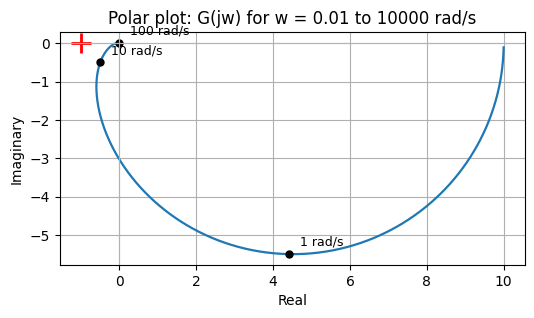

In [25]:
omega = np.logspace(-2, 4, 2000)
mag, phase, w = ct.frequency_response(G_f, omega)
Gjw = mag * np.exp(1j * phase)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(Gjw.real, Gjw.imag, lw=1.6)
ax.plot(-1, 0, 'r+', markersize=14, markeredgewidth=2)

# Mark a few frequencies so the direction of travel is obvious
for target in (1, 10, 100):
    i = np.argmin(np.abs(w - target))
    ax.plot(Gjw.real[i], Gjw.imag[i], 'ko', markersize=5)
    ax.annotate(f'{target} rad/s', (Gjw.real[i], Gjw.imag[i]),
                textcoords='offset points', xytext=(8, 6), fontsize=9)

ax.axhline(0, color='0.7', lw=0.8); ax.axvline(0, color='0.7', lw=0.8)
ax.set_xlabel('Real'); ax.set_ylabel('Imaginary')
ax.set_title('Polar plot: G(jw) for w = 0.01 to 10000 rad/s')
ax.set_aspect('equal')
plt.show()

---
## 11. Week 12 — Relative stability and the Nichols chart

Nise §10.9 covers the Nichols chart via M and N circles. `ct.nichols_grid()` is the direct equivalent
of MATLAB's `ngrid`.

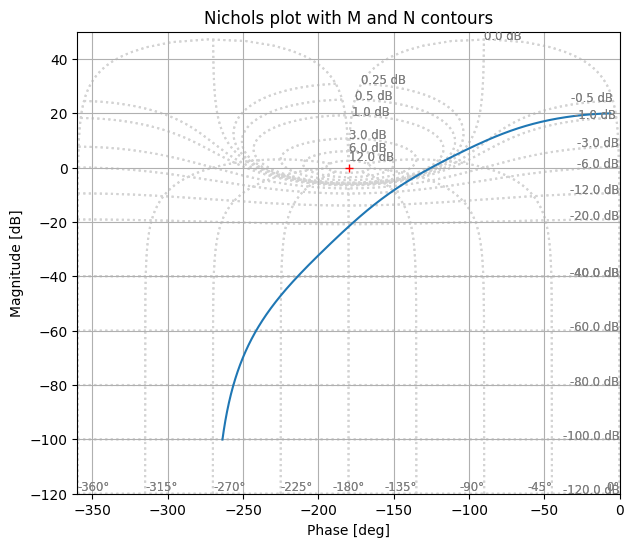

In [26]:
fig, ax = plt.subplots(figsize=(7, 6))
ct.nichols_plot(G_f, ax=ax)
ct.nichols_grid()
ax.set_title('Nichols plot with M and N contours')
plt.show()

In [27]:
# MATLAB: allmargin(G)
# NOTE: ct.stability_margins returns SIX values, and the third is the
# stability margin (the minimum distance from the Nyquist plot to -1),
# NOT the delay margin. MATLAB's allmargin reports a delay margin; this
# does not. Compute the delay margin yourself -- see below.
gm, pm, sm, wpc, wgc, wms = ct.stability_margins(G_f)

print(f"Gain margin           : {gm:.4f} (ratio) = {20*np.log10(gm):.3f} dB")
print(f"  at phase crossover  : {wpc:.4f} rad/s")
print(f"Phase margin          : {pm:.4f} deg")
print(f"  at gain crossover   : {wgc:.4f} rad/s")
print(f"Stability margin      : {sm:.4f}  (closest approach to -1)")
print(f"  at frequency        : {wms:.4f} rad/s")

# Delay margin = phase margin (in radians) / gain crossover frequency
delay_margin = np.radians(pm) / wgc
print(f"Delay margin          : {delay_margin:.4f} s")

# Closed-loop resonant peak and bandwidth
T = ct.feedback(G_f, 1)
mag_cl, _, w_cl = ct.frequency_response(T, np.logspace(-2, 4, 4000))
Mr = mag_cl.max()
wr = w_cl[np.argmax(mag_cl)]

print(f"\nResonant peak Mr      : {Mr:.4f} = {20*np.log10(Mr):.3f} dB")
print(f"Resonant frequency wr : {wr:.4f} rad/s")
print(f"Bandwidth             : {ct.bandwidth(T):.4f} rad/s")

Gain margin           : 12.2210 (ratio) = 21.742 dB
  at phase crossover  : 33.3167 rad/s
Phase margin          : 54.9014 deg
  at gain crossover   : 7.7980 rad/s
Stability margin      : 0.6660  (closest approach to -1)
  at frequency        : 12.0172 rad/s
Delay margin          : 0.1229 s

Resonant peak Mr      : 1.0848 = 0.707 dB
Resonant frequency wr : 7.7041 rad/s
Bandwidth             : 13.4909 rad/s


---
## 12. What has no Python equivalent

Be honest with yourself about these three before choosing a toolchain.

### Simulink — no substitute

**Week 9's tutorial and Assignment 4 use Simulink, and you should use Simulink for them.** Packages
like `bdsim` and the Modelica-based tools exist but are nowhere near as mature, and more importantly
they lose the point of the exercise: you draw a block diagram by hand in Week 4 and then build *that
same diagram* and run it. A Python script breaks the visual link that makes the exercise worth doing.

If you have no MATLAB access at all, talk to me — do not silently substitute a script.

### `sisotool` — a partial equivalent exists

`ct.sisotool(G)` exists and gives an interactive design window, but it needs an interactive matplotlib
backend (`%matplotlib qt` or `%matplotlib widget`) and is less capable than MATLAB's
`controlSystemDesigner`. It is adequate for FEE3411's Week 9 and will feel thin in FEE3412.

### `rlocfind` — click-to-select

No equivalent. Use the `locus_at_gain` and `gain_for_damping` helpers from §7 instead. Arguably an
improvement, since you have to state what you are solving for.

---

## Summary

| Task | Recommended tool |
|---|---|
| Checking a hand-drawn root locus, Bode plot or Nyquist diagram | either |
| Transfer function algebra, step response, error constants | either |
| Routh array with a symbolic gain | **Python** (sympy) — MATLAB needs the Symbolic Toolbox |
| Block-diagram simulation (Week 9, Assignment 4) | **MATLAB/Simulink** — no substitute |
| Interactive compensator design (mostly FEE3412) | **MATLAB** |

Whichever you use: **draw it by hand first.** The plotting command is how you find out whether you were
right, not how you get the answer.
